<a href="https://colab.research.google.com/github/luisleonb/Proyecto_M6_ABP/blob/main/Proyecto_M6_Luis_Le%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Proyecto Módulo 6: Predicción inteligente de gasto en clientes e-commerce

##Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures, RobustScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings; warnings.filterwarnings('ignore')

##Lección 1: Fundamentos del Aprendizaje de Máquina

Se identificó que el problema consiste en predecir el monto de compra, una variable numérica, lo que define un problema de aprendizaje supervisado de regresión. Se cuenta con un dataset de 5000 registros, donde se observan variables demográficas y de comportamiento digital. No se detectaron valores nulos críticos en la carga inicial.

En cuanto a las etapas del pipeline del proyecto, este comienza en la limpieza de datos, pasa por la transformación de variables y culmina en la evaluación de la capacidad predictiva del algoritmo.

####Etapas del pipeline ML:

1.   Carga
2.   Prepocesamiento
3.   Train/Test
4.   Evaluación
5.   Optimización


####Tipo de Problema
El problema es de regresión supervisada



In [2]:
# CARGAR DATOS
df = pd.read_csv('ecommerce_customer_behavior_dataset.csv')
print("Shape inicial:", df.shape)
print("\nTarget: Total_Amount (regresión continua)")
print("="*100)
print(df['Total_Amount'].describe())
print("="*100)
print(df.info())


Shape inicial: (5000, 18)

Target: Total_Amount (regresión continua)
count     5000.000000
mean       983.108914
std       1898.978528
min          7.870000
25%        122.517500
50%        337.910000
75%        979.695000
max      22023.900000
Name: Total_Amount, dtype: float64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order_ID                  5000 non-null   object 
 1   Customer_ID               5000 non-null   object 
 2   Date                      5000 non-null   object 
 3   Age                       5000 non-null   int64  
 4   Gender                    5000 non-null   object 
 5   City                      5000 non-null   object 
 6   Product_Category          5000 non-null   object 
 7   Unit_Price                5000 non-null   float64
 8   Quantity                  5000 non-null   int64  
 9   Dis

In [3]:
df.columns.to_list()

['Order_ID',
 'Customer_ID',
 'Date',
 'Age',
 'Gender',
 'City',
 'Product_Category',
 'Unit_Price',
 'Quantity',
 'Discount_Amount',
 'Total_Amount',
 'Payment_Method',
 'Device_Type',
 'Session_Duration_Minutes',
 'Pages_Viewed',
 'Is_Returning_Customer',
 'Delivery_Time_Days',
 'Customer_Rating']

##Limpieza pre-pipeline (Outliers/Nulos)

In [4]:
# Limpieza básica
df_clean = df.dropna()
Q1, Q3 = df_clean['Total_Amount'].quantile([0.25, 0.75])
iqr = Q3 - Q1
df_clean = df_clean[(df_clean['Total_Amount'] >= Q1-1.5*iqr) &
                   (df_clean['Total_Amount'] <= Q3+1.5*iqr)]
print(f"Filas: {len(df)} → {len(df_clean)}")

# Features principales
num = ['Age', 'Unit_Price', 'Discount_Amount', 'Session_Duration_Minutes', 'Pages_Viewed', 'Delivery_Time_Days', 'Customer_Rating']
cat = ['Gender', 'Product_Category', 'Payment_Method']
X = df_clean[num + cat]
y = df_clean['Total_Amount']

# Separación de los datos para test y train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Filas: 5000 → 4454


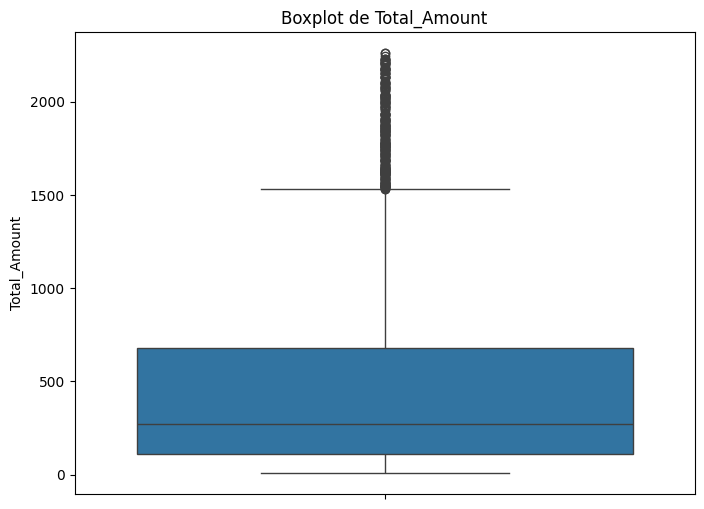

In [5]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df_clean['Total_Amount'])
plt.title('Boxplot de Total_Amount')
plt.ylabel('Total_Amount')
plt.savefig('boxplot_total_amount.png')
plt.show()

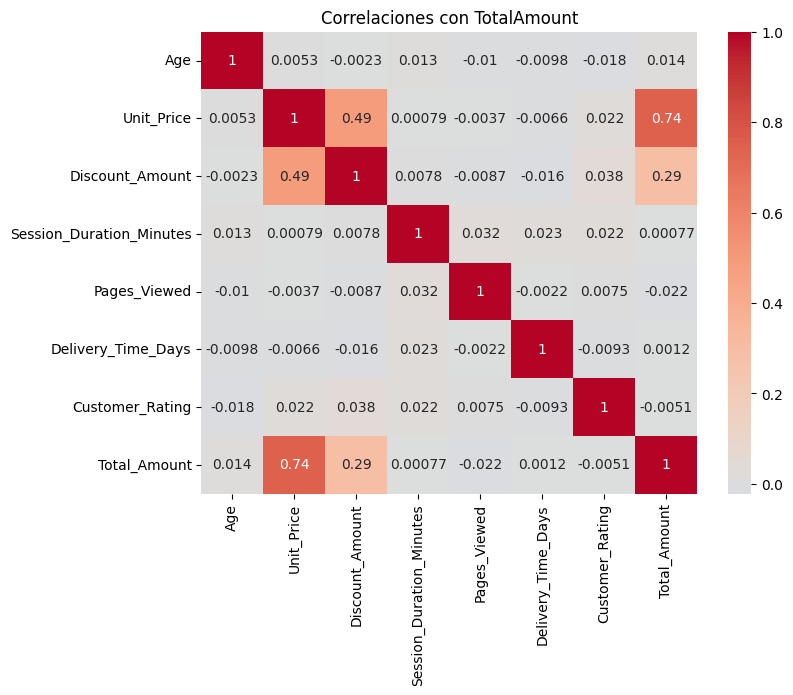


Corrs con TotalAmount:
Total_Amount                1.000000
Unit_Price                  0.744288
Discount_Amount             0.291356
Age                         0.014359
Delivery_Time_Days          0.001216
Session_Duration_Minutes    0.000768
Customer_Rating            -0.005062
Pages_Viewed               -0.021697
Name: Total_Amount, dtype: float64


<Figure size 640x480 with 0 Axes>

In [6]:
#Análisis de correlaciones
corr_matrix = df_clean[num + ['Total_Amount']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlaciones con TotalAmount')
plt.show()
plt.savefig('correlaciones.png')
print("\nCorrs con TotalAmount:")
print(corr_matrix['Total_Amount'].sort_values(ascending=False))

##Lección 3: Preprocesamiento y escalamiento de datos

In [7]:
# PREPROCESADOR reutilizable
scaler = RobustScaler() #para las variables numéricas
#se uso RobustScaler para ver la diferencia con StandardScaler y ver si tiene mejor manejo de outliers
categorical = OneHotEncoder(drop='first', sparse_output=False) #para variables categóricas

preprocessor = ColumnTransformer([
    ('num', scaler, num),
    ('cat', categorical, cat)
])

print("Pipeline preprocessor listo")

Pipeline preprocessor listo


##Lección 2 Validacion

In [8]:
# PIPELINE SIMPLE para evaluar ajuste
pipeline_base = Pipeline([
    ('preprocess', preprocessor),
    ('model', LinearRegression())
])

pipeline_base.fit(X_train, y_train)


y_train_pred = pipeline_base.predict(X_train)
y_test_pred = pipeline_base.predict(X_test)


# 2. Calcular errores (MAE)
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

print("Ajuste del modelo:")
print(f"Error Entrenamiento (MAE): {mae_train:.3f}")
print(f"R² Train: {pipeline_base.score(X_train, y_train):.3f}")
print(f"Error prueba (MAE): {mae_test:.3f}")
print(f"R² Test:  {pipeline_base.score(X_test, y_test):.3f}")

# K-Folds CV
val_cruzada = cross_val_score(pipeline_base, X, y, cv=5, scoring='r2')
print("="*100)
print(f"Resultados de los Fold: {val_cruzada}")
print("="*100)
print(f"CV R² + desviación estándar: {val_cruzada.mean():.3f} ± {val_cruzada.std():.3f}")


Ajuste del modelo:
Error Entrenamiento (MAE): 229.999
R² Train: 0.597
Error prueba (MAE): 225.599
R² Test:  0.603
Resultados de los Fold: [0.60764635 0.58600842 0.61157979 0.57251539 0.58739002]
CV R² + desviación estándar: 0.593 ± 0.015


Según los resultados del modelo, no se aprecia que haya sobreajuste o subajuste. Tiene una baja desviación estándar.

Con un R² de 0.603, el modelo puede explicar alrededor del 60.3% de la variabilidad del gasto de los clientes.

##Lección 4: Regresiones

In [9]:
# LINEAL
pipeline_linear = Pipeline(pipeline_base.steps)
y_pred_linear = pipeline_linear.predict(X_test)

# POLINOMIAL
pipeline_poly = Pipeline([
    ('preprocess', preprocessor),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('model', LinearRegression())
])

pipeline_poly.fit(X_train, y_train)
y_pred_poly = pipeline_poly.predict(X_test)

print("Regresiones:")
print(f"Lineal R²: {pipeline_linear.score(X_test, y_test):.3f}")
print(f"Poly R²:   {pipeline_poly.score(X_test, y_test):.3f}")


Regresiones:
Lineal R²: 0.603
Poly R²:   0.603


Si tenemos los mismos resulados de R² para la regresión lineal y polinomial quiere decir que agregar términos cuadrados a la ecuación no aporta nueva información que no haya sido capturada por la regresión lineal. Esto también quiere decir que es mejor optar por el modelo más simple.

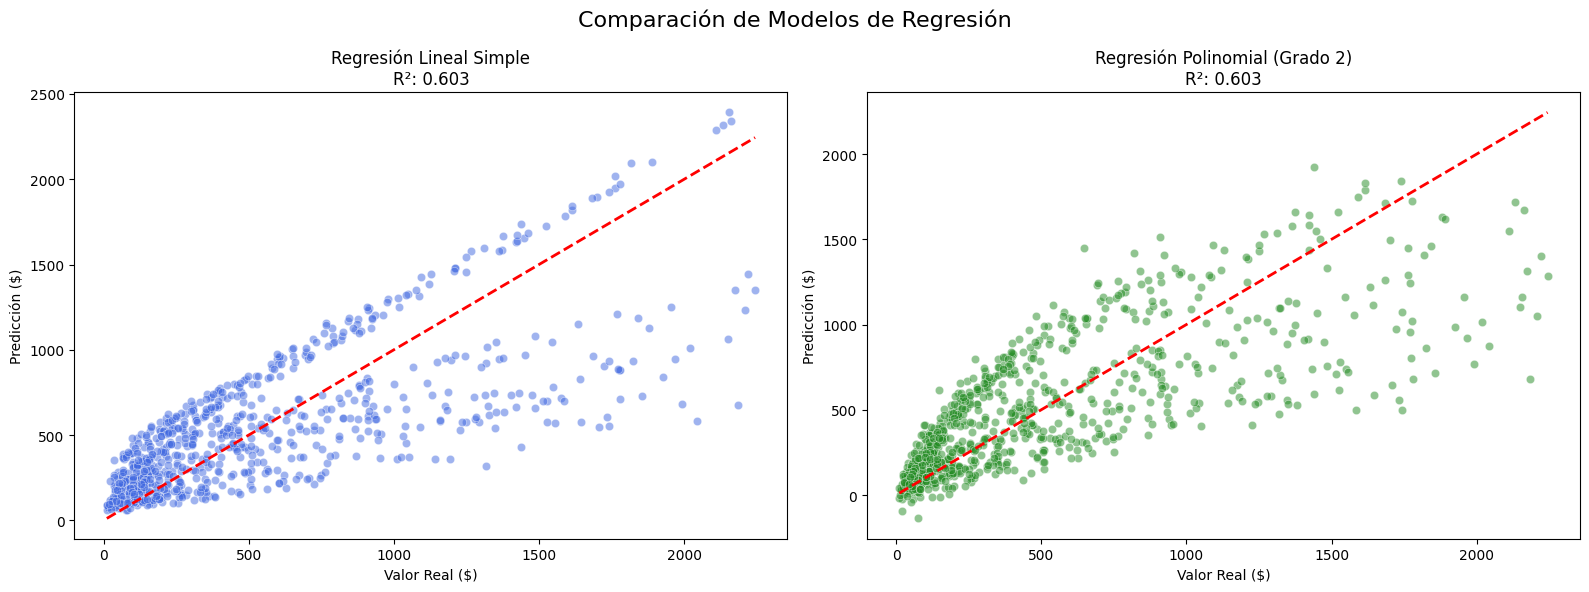

In [10]:
#Comparación Lineal - Polinomial

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico Regresión Lineal
sns.scatterplot(x=y_test, y=y_pred_linear, ax=ax1, color='royalblue', alpha=0.5)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax1.set_title(f'Regresión Lineal Simple\nR²: {pipeline_linear.score(X_test, y_test):.3f}', fontsize=12)
ax1.set_xlabel('Valor Real ($)')
ax1.set_ylabel('Predicción ($)')

# Gráfico Regresión Polinomial
sns.scatterplot(x=y_test, y=y_pred_poly, ax=ax2, color='forestgreen', alpha=0.5)
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax2.set_title(f'Regresión Polinomial (Grado 2)\nR²: {pipeline_poly.score(X_test, y_test):.3f}', fontsize=12)
ax2.set_xlabel('Valor Real ($)')
ax2.set_ylabel('Predicción ($)')

plt.suptitle('Comparación de Modelos de Regresión', fontsize=16)
plt.tight_layout()
plt.savefig('regression_comparison.png')
plt.show()

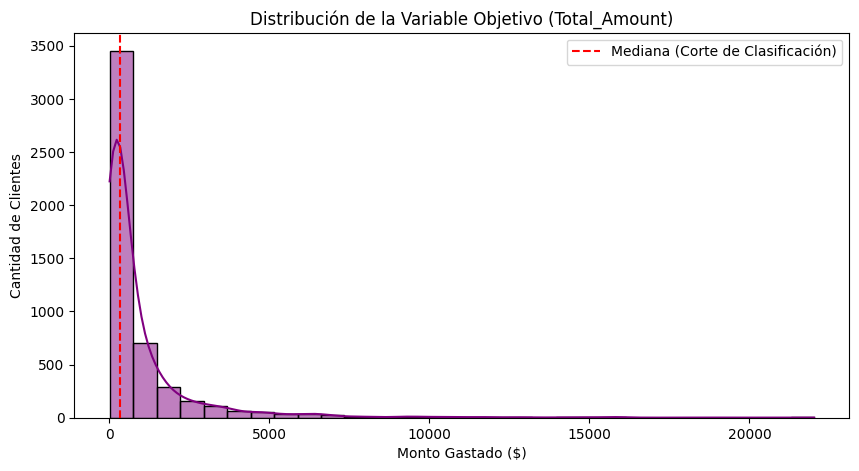

In [11]:
# --- DISTRIBUCIÓN DEL TARGET ---
plt.figure(figsize=(10, 5))
sns.histplot(df['Total_Amount'], kde=True, color='purple', bins=30)
plt.axvline(df['Total_Amount'].median(), color='red', linestyle='--', label='Mediana (Corte de Clasificación)')
plt.title('Distribución de la Variable Objetivo (Total_Amount)')
plt.xlabel('Monto Gastado ($)')
plt.ylabel('Cantidad de Clientes')
plt.legend()
plt.savefig('target_distribution.png')
plt.show()

##Lección 5: Algoritmos de clasificación

In [12]:
# Simula binario para clasificación (¿por qué NO usar?)
y_binary = (y > y.median()).astype(int)
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X, y_binary, test_size=0.2, random_state=42)

pipeline_knn_class = Pipeline([
    ('preprocess', preprocessor),
    ('knn', KNeighborsRegressor(n_neighbors=5))  # Regresor KNN para comparar
])
pipeline_knn_class.fit(X_train_b, y_train_b)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', RobustScaler(),
                                                  ['Age', 'Unit_Price',
                                                   'Discount_Amount',
                                                   'Session_Duration_Minutes',
                                                   'Pages_Viewed',
                                                   'Delivery_Time_Days',
                                                   'Customer_Rating']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['Gender', 'Product_Category',
                                                   'Payment_Method'])])),
                ('knn', KNeighborsRegressor())])

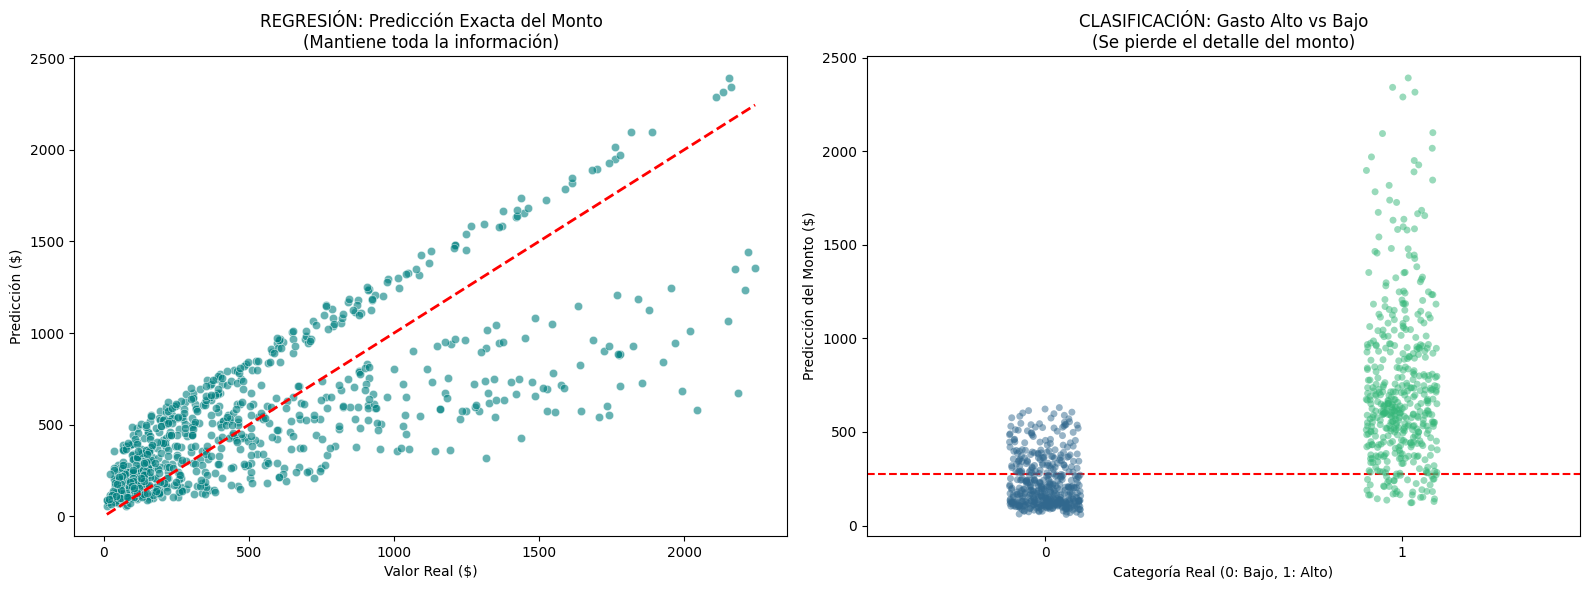

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Gráfico de Regresión (El correcto para el proyecto)
# Comparamos el valor real vs la predicción numérica
sns.scatterplot(x=y_test, y=y_pred_linear, ax=ax1, color='teal', alpha=0.6)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax1.set_title('REGRESIÓN: Predicción Exacta del Monto\n(Mantiene toda la información)', fontsize=12)
ax1.set_xlabel('Valor Real ($)')
ax1.set_ylabel('Predicción ($)')

# 2. Gráfico de Clasificación (Lo que simulaba el bloque de código)
# Mostramos cómo se agrupan en 0 y 1 (perdiendo los matices)
y_test_binary = (y_test > y.median()).astype(int)
y_pred_binary = (y_pred_linear > y.median()).astype(int)
sns.stripplot(x=y_test_binary, y=y_pred_linear, ax=ax2, jitter=True, alpha=0.5, palette='viridis')
ax2.axhline(y=y.median(), color='red', linestyle='--', label='Umbral Mediana')
ax2.set_title('CLASIFICACIÓN: Gasto Alto vs Bajo\n(Se pierde el detalle del monto)', fontsize=12)
ax2.set_xlabel('Categoría Real (0: Bajo, 1: Alto)')
ax2.set_ylabel('Predicción del Monto ($)')

plt.tight_layout()
plt.savefig('regression_vs_classification.png')
plt.show()

Como la variable Total_Amount es continua se recomienda utilizar un modelo de regresión. Como se ve de forma gráfica, con un modelo de clasificación se pierden detalles.

##Lección 6: Métricas de desempeño

Tabla Métricas:
       Modelo      MAE     RMSE     R²
0      Lineal  225.599  312.984  0.603
1  Polinomial  223.061  312.899  0.603


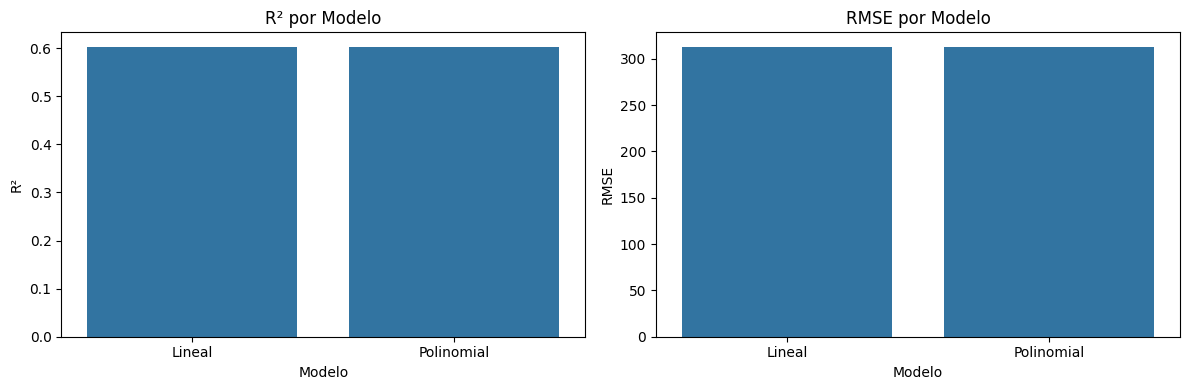

In [14]:
# Función métricas
def metrics_table(y_true, y_preds, names):
    results = []
    for name, y_pred in zip(names, y_preds):
        results.append({
            'Modelo': name,
            'MAE': mean_absolute_error(y_true, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
            'R²': r2_score(y_true, y_pred)
        })
    return pd.DataFrame(results).round(3)

# Predicciones
preds = [pipeline_linear.predict(X_test), pipeline_poly.predict(X_test)]
names = ['Lineal', 'Polinomial']
tabla = metrics_table(y_test, preds, names)
print("Tabla Métricas:")
print(tabla)
print("="*100)

# Visual
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=tabla, x='Modelo', y='R²', ax=axes[0])
axes[0].set_title('R² por Modelo')
sns.barplot(data=tabla, x='Modelo', y='RMSE', ax=axes[1])
axes[1].set_title('RMSE por Modelo')
plt.tight_layout()
plt.savefig('metrics_comparison.png')
plt.show()


Aunque el modelo Polinomial presenta un MAE ligeramente menor ($223.06$ vs $225.59$), la ganancia en precisión es marginal ($<1\%$) y el $R^2$ se mantiene idéntico. Dado que el RMSE también es casi igual, se concluye que la complejidad adicional de los términos polinomiales no justifica su uso. Se recomienda proceder con la Regresión Lineal por su mayor interpretabilidad y menor riesgo de sobreajuste, o saltar directamente a modelos de Boosting si se busca romper la barrera del 0.60

##Lección 7: Optimización del modelo

In [15]:
# Ejemplo de Ingeniería de Características:
# Creamos una interacción entre Edad y Duración de Sesión
#df['Age_x_Session'] = df['Age'] * df['Session_Duration']

In [16]:
# Ridge con GridSearch
pipeline_ridge = Pipeline([
    ('preprocess', preprocessor),
    ('ridge', Ridge())
])
param_grid_ridge = {'ridge__alpha': [0.1, 1.0, 10.0]} # Corrected parameter name
grid_ridge = GridSearchCV(pipeline_ridge, param_grid_ridge, cv=5, scoring='r2')
grid_ridge.fit(X_train, y_train)
#print(f"Ridge mejor: {grid_ridge.best_params_}")
#print(f"Ridge R²: {grid_ridge.score(X_test, y_test):.3f}")

# Lasso
pipeline_lasso = Pipeline([
    ('preprocess', preprocessor),
    ('lasso', Lasso())
])

param_grid_lasso = {'lasso__alpha': [0.1, 1.0, 10.0]}
grid_lasso = GridSearchCV(pipeline_lasso, param_grid_lasso, cv=5, scoring='r2')
grid_lasso.fit(X_train, y_train)

#Agrega lasso a tabla
y_pred_lasso = grid_lasso.predict(X_test)
tabla.loc[len(tabla)] = metrics_table(y_test, [y_pred_lasso], ['Lasso CV']).iloc[0]


# Agrega a tabla
y_pred_ridge = grid_ridge.predict(X_test)
tabla.loc[len(tabla)] = metrics_table(y_test, [y_pred_ridge], ['Ridge CV']).iloc[0]
print(tabla)

       Modelo      MAE     RMSE     R²
0      Lineal  225.599  312.984  0.603
1  Polinomial  223.061  312.899  0.603
2    Lasso CV  225.632  312.629  0.603
3    Ridge CV  225.607  312.887  0.603


Tanto Lasso como Ridge no tienen mayor impacto, teniendo incluso mayor MAE que la regresión Lineal con un R² igual.

##Lección 8: Algoritmos de Boosting

In [17]:
# Gradient Boosting
pipeline_gb = Pipeline([
    ('preprocess', preprocessor),
    ('gb', GradientBoostingRegressor(n_estimators=200, random_state=42))
])
pipeline_gb.fit(X_train, y_train)
y_pred_gb = pipeline_gb.predict(X_test)

print("Boosting (Ensemble superior para no-linealidades)")
print(f"GB R²: {pipeline_gb.score(X_test, y_test):.3f}")
print("="*100)
# Tabla FINAL
tabla.loc[len(tabla)] = metrics_table(y_test, [y_pred_gb], ['GradientBoosting']).iloc[0]
print("\n🎯 TABLA FINAL - MODELO GANADOR:", tabla.style.highlight_max(axis=0).to_string())

# Feature Importance (GB)
#importances = pipeline_gb.named_steps['gb'].feature_importances_
#feature_names = num + list(preprocessor.named_transformers_['cat'].get_feature_names_out())
#plt.figure(figsize=(10,6))
#sns.barplot(x=importances[:10], y=feature_names[:10])  # Top 10
#plt.title('Feature Importance - Gradient Boosting')
#plt.savefig('feature_importance_gb.png')
#plt.show()

Boosting (Ensemble superior para no-linealidades)
GB R²: 0.609

🎯 TABLA FINAL - MODELO GANADOR:  Modelo MAE RMSE R²
0 Lineal 225.599000 312.984000 0.603000
1 Polinomial 223.061000 312.899000 0.603000
2 Lasso CV 225.632000 312.629000 0.603000
3 Ridge CV 225.607000 312.887000 0.603000
4 GradientBoosting 218.451000 310.251000 0.609000



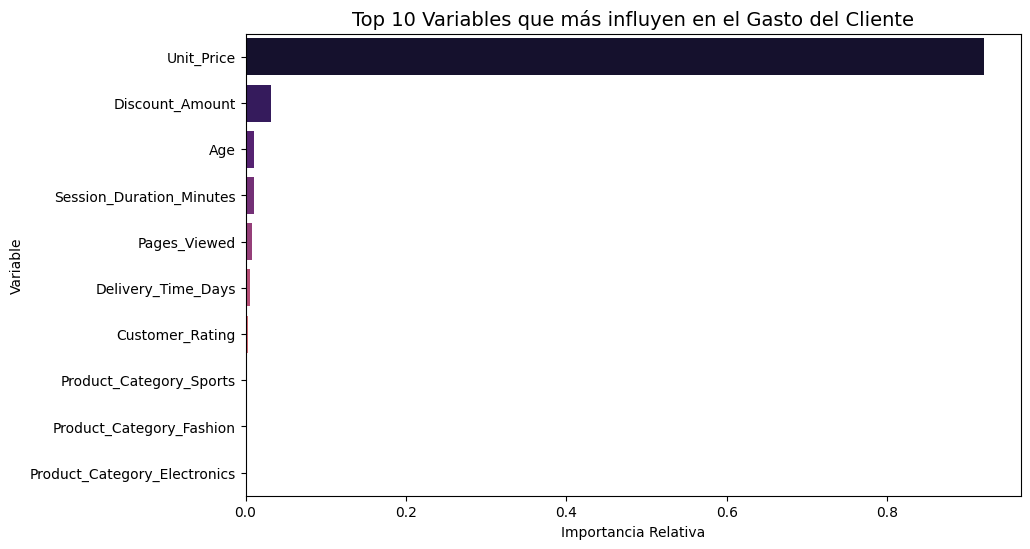

In [18]:
# --- GRÁFICA LECCIÓN 8: IMPORTANCIA DE VARIABLES ---
# Asumiendo que tu pipeline se llama pipeline_gb
importances = pipeline_gb.named_steps['gb'].feature_importances_
features = num + list(pipeline_gb.named_steps['preprocess'].transformers_[1][1].get_feature_names_out())

# Crear un DataFrame para graficar
feat_imp = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_imp = feat_imp.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='magma')
plt.title('Top 10 Variables que más influyen en el Gasto del Cliente', fontsize=14)
plt.xlabel('Importancia Relativa')
plt.ylabel('Variable')
plt.savefig('feature_importance_gb.png')
plt.show()

##Conclusiones
